<a href="https://colab.research.google.com/github/Yasmeen20110210/Final_Project/blob/main/01_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

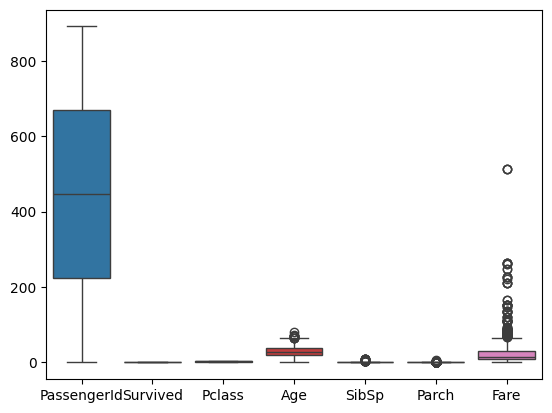

Nulls in Age: 0
All Fare > 0: False
Final Shape: (891, 12)


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Import everything I need

titanic = pd.read_csv("train.csv")
# Load the dataset
print("First 5 rows:", titanic.head())
# Show the first 5 rows
print("Shape:", titanic.shape)
# Show the shape
print("Info:", titanic.info())
# Show the info
print("Missing Values:", titanic.isnull().sum())
# Check if there's any missing values
print("Duplicates:", titanic.duplicated().sum())
# Check for any duplicates

sns.boxplot(titanic)
plt.show()
# Draw a boxplot to see if there are any outliers

def clean_data(df):

    df = titanic.copy()
    df["Survived"] = df["Survived"].astype("category")
     # Make sure that the type is category
    df["Pclass"] = df["Pclass"].astype("category")
    # Make sure that the type is category
    df["Age"] = df["Age"].fillna(df["Age"].median())
    # Fill the missing ages with the median of the ages
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
    # Fill the missing embraked with the mode of it
    df.drop_duplicates(inplace=True)
    # Drop any duplicates
    Q1 = df["Fare"].quantile(0.25)
    Q3 = df["Fare"].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df["Fare"] = df["Fare"].clip(lower, upper)
    # Cap fare with the lower and the upper that I found using IQR method

    return df

titanic_clean = clean_data(titanic)

print("Nulls in Age:", titanic_clean["Age"].isnull().sum())
# Check that the age column has no missing
print("All Fare > 0:", (titanic_clean["Fare"] > 0).all())
# Check that all fares are greater than 0
print("Final Shape:", titanic_clean.shape)
# See the final shape
